# Machine Learning Lab: Apple or Orange? 🍎🍊

We will teach a computer to tell **apples** from **oranges** using just two measurements:

| Feature | What it means |
|---|---|
| `weight` | how heavy the fruit is, in grams |
| `texture` | how bumpy the skin is, from 1 (very smooth) to 10 (very bumpy) |

Along the way you will:

1. **Look** at the data and find the problems in it
2. **Clean** it
3. **Split** it into a training set and a test set, and see why the split matters
4. **Prepare** it (fill gaps, scale the numbers)
5. **Train** a simple classifier
6. **Measure** how good it is, with numbers and pictures

Cells marked **Exercise** have a `...` for you to replace. Run every cell in order with **Shift + Enter**.

> The fruit data is made up for this lab.

## Part 0: Setup
Run this cell to load the tools we need.

In [1]:
import numpy as np                    # maths tools
import pandas as pd                   # tables of data
import matplotlib.pyplot as plt       # charts

from sklearn.model_selection import train_test_split     # splits data into train and test
from sklearn.preprocessing import StandardScaler         # scales numbers
from sklearn.neighbors import KNeighborsClassifier       # our classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

## Part 1: The data
Run this cell to create the fruit data. You don't need to change it.

In [2]:
rng = np.random.default_rng(0)     # makes the "random" data the same for everyone

# 60 apples: usually a bit lighter, with smooth skin
apples = pd.DataFrame({"weight":  rng.normal(160, 20, 60).round(),
                       "texture": rng.normal(3, 1.3, 60).round(1).clip(1, 10),
                       "fruit":   "apple"})

# 60 oranges: usually a bit heavier, with bumpy skin
oranges = pd.DataFrame({"weight":  rng.normal(180, 20, 60).round(),
                        "texture": rng.normal(6, 1.3, 60).round(1).clip(1, 10),
                        "fruit":   "orange"})

fruit = pd.concat([apples, oranges], ignore_index=True)   # all the apples first, then all the oranges

# Real data is messy, so we add some mistakes on purpose
fruit.loc[[3, 17, 70, 95], "fruit"] = ["Apple", "apple ", "ORANGE", "Orange"]   # inconsistent labels
fruit.loc[[8, 44, 81, 110], "weight"] = np.nan                                 # missing weights
fruit = pd.concat([fruit, fruit.loc[[5, 66, 90]]], ignore_index=True)           # 3 duplicated rows

print("We have", len(fruit), "fruits")

We have 123 fruits


### Exercise 1.1: Have a look
Show the first 10 rows of the table.

In [3]:
fruit.head(10)     # TODO: replace ... with how many rows to show

,weight,texture,fruit
0,163.0,2.4,apple
1,157.0,1.5,apple
2,173.0,5.3,apple
3,162.0,2.4,Apple
4,149.0,3.4,apple
5,167.0,2.7,apple
6,186.0,5.1,apple
7,179.0,4.7,apple
8,NaN,3.8,apple
9,135.0,1.0,apple


### Exercise 1.2: Find the problems
Count the fruit labels, the missing values and the duplicate rows.

In [4]:
print(fruit["fruit"].value_counts())           # how many of each label
print()
print("Missing values:")
print(fruit.isna().sum())                      # how many gaps in each column
print()
print("Duplicate rows:", fruit.duplicated().sum())                  # TODO: use fruit.duplicated().sum()

fruit
orange    60
apple     59
Apple      1
apple      1
ORANGE     1
Orange     1
Name: count, dtype: int64

Missing values:
weight     4
texture    0
fruit      0
dtype: int64

Duplicate rows: 3


**Question 1:** What three problems did you find?

*Your answer:*
    1. There are some missing value.
    2. There are duplicate rows.
    3. The label in "fruit" column are not unified.

P.S. In VSCode, you need to run each cell by clicking the "Run" buttom manually. If you click "Run All", it will occur this error "TypeError: 'ellipsis' object is not subscriptable".

## Part 2: Clean the data
### Exercise 2.1: Fix the labels and remove duplicates

In [5]:
fruit["fruit"] = fruit["fruit"].str.strip().str.lower()   # " Apple " -> "apple"
fruit = fruit.drop_duplicates()                                                # TODO: remove duplicate rows (hint: .drop_duplicates())

print(fruit["fruit"].value_counts())
print("Fruits left:", len(fruit))

fruit
apple     60
orange    60
Name: count, dtype: int64
Fruits left: 120


We will fill in the **missing weights** later, after splitting, because filling them uses an average and we must only learn averages from the training data.

## Part 3: Picture the data
### Exercise 3.1: Scatter plot
Plot every fruit with **weight** across the bottom and **texture** up the side.

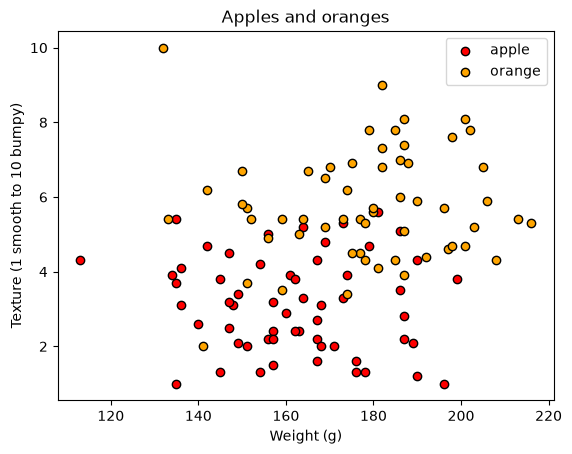

In [6]:
for name, colour in [("apple", "red"), ("orange", "orange")]:
    rows = fruit[fruit["fruit"] == name]                     # just this type of fruit
    plt.scatter(rows["weight"], rows["texture"], c=colour, label=name, edgecolor="black")   # TODO: which two columns?

plt.xlabel("Weight (g)")
plt.ylabel("Texture (1 smooth to 10 bumpy)")
plt.legend()
plt.title("Apples and oranges")
plt.show()

**Question 3:** Which feature separates apples from oranges better: weight or texture? Do the two groups overlap?

*Your answer:*
    "texture" separates apples from oranges better. Yes, the two groups have a little overlap.

## Part 4: Split into training and test sets
The model **learns** from the training set. We keep the test set hidden until the end to check it on fruit it has **never seen**.

### Exercise 4.1: Split 75% / 25%

In [7]:
X = fruit[["weight", "texture"]]     # the features (what the model looks at)
y = fruit["fruit"]                   # the label (what we want it to predict)

# TODO: replace ... with 0.25 so a quarter of the fruit goes into the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Training fruits:", len(X_train))
print("Test fruits:    ", len(X_test))
print()
print("Test set contains:")
print(y_test.value_counts())

Training fruits: 90
Test fruits:     30

Test set contains:
fruit
apple     15
orange    15
Name: count, dtype: int64


### Exercise 4.2: What goes wrong with a bad split?
Our table has **all the apples first, then all the oranges**. What happens if we split it **without shuffling**?

In [8]:
# TODO: set shuffle to False
_, _, y_train_bad, y_test_bad = train_test_split(X, y, test_size=0.25, shuffle=False)

print("Training set contains:")
print(y_train_bad.value_counts())
print()
print("Test set contains:")
print(y_test_bad.value_counts())

Training set contains:
fruit
apple     60
orange    30
Name: count, dtype: int64

Test set contains:
fruit
orange    30
Name: count, dtype: int64


**Question 4:** What is wrong with this split? Why is shuffling (and `stratify=y`) important?

*Your answer:*
    There are only "orange" but no "apple" in the Test set. The shuffling is important is because it make sure the sequence order does not affect too much to the set splitting. And 'stratify=y' is to make sure the percentage of "apple" and "orangein Train set and Test set are same as the original set.

## Part 5: Prepare the data
Two jobs, both learned from the **training set only**:
1. Fill the missing weights with the **median** (middle value) of the training weights
2. **Scale** both features so weight (hundreds of grams) doesn't drown out texture (1 to 10)

### Exercise 5.1: Fill the gaps

In [9]:
median_weight = X_train["weight"].median()              # TODO: add .median()
print("Median training weight:", median_weight)

X_train = X_train.fillna(median_weight)
X_test = X_test.fillna(median_weight)                       # TODO: fill the test set with the SAME value

print("Gaps left:", X_train.isna().sum().sum() + X_test.isna().sum().sum())

Median training weight: 170.5
Gaps left: 0


### Exercise 5.2: Scale the features

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # learn average and spread from TRAINING data, then scale
X_test_scaled = scaler.transform(X_test)                # TODO: use .transform (NOT fit_transform) on the test data

print("First 3 training fruits before scaling:")
print(X_train.head(3))
print()
print("The same fruits after scaling:")
print(X_train_scaled[:3].round(2))

First 3 training fruits before scaling:
    weight  texture
86   142.0      6.2
58   136.0      4.1
8    170.5      3.8

The same fruits after scaling:
[[-1.4   0.97]
 [-1.7  -0.18]
 [ 0.02 -0.34]]


## Part 6: Train a classifier
We use **k-nearest neighbours (KNN)**. To label a new fruit, it finds the **5 most similar fruits** in the training set and goes with the majority.

### Exercise 6.1: Train and test

In [11]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)                                 # TODO: train on X_train_scaled and y_train

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)               # TODO: score on the test set

print(f"Training accuracy: {train_accuracy:.0%}")
print(f"Test accuracy:     {test_accuracy:.0%}")

Training accuracy: 87%
Test accuracy:     87%


### Exercise 6.2: Classify a new fruit
A fruit weighs **170 g** and has a texture of **7**. What does the model think it is?

In [12]:
new_fruit = pd.DataFrame({"weight": [170], "texture": [7]})    # TODO: fill in the texture
new_fruit_scaled = scaler.transform(new_fruit)                   # scale it the same way as the training data

print("The model says:", model.predict(new_fruit_scaled)[0])

The model says: orange


### Exercise 6.3: Does scaling matter?
Train the same model on the **unscaled** numbers and compare.

In [13]:
model_unscaled = KNeighborsClassifier(n_neighbors=5)
model_unscaled.fit(X_train, y_train)                        # TODO: train on the UNSCALED X_train and y_train

print(f"Test accuracy without scaling: {model_unscaled.score(X_test, y_test):.0%}")
print(f"Test accuracy with scaling:    {test_accuracy:.0%}")

Test accuracy without scaling: 73%
Test accuracy with scaling:    87%


**Question 6:** Why is the unscaled model worse? *(Hint: a difference of 20 g in weight and a difference of 3 in texture: which looks bigger to the computer? Which one actually matters more?)*

*Your answer:*

## Part 7: Does the split change the result?
This helper repeats Parts 4 to 6 for a different random split. It is written for you.

In [14]:
def test_accuracy_for_split(seed):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
    med = X_tr["weight"].median()
    X_tr, X_te = X_tr.fillna(med), X_te.fillna(med)
    sc = StandardScaler().fit(X_tr)
    knn = KNeighborsClassifier(n_neighbors=5).fit(sc.transform(X_tr), y_tr)
    return knn.score(sc.transform(X_te), y_te)

print(f"Split 42 gives {test_accuracy_for_split(42):.0%}")   # should match Exercise 6.1

Split 42 gives 87%


### Exercise 7.1: Try 20 different splits and draw a bar chart

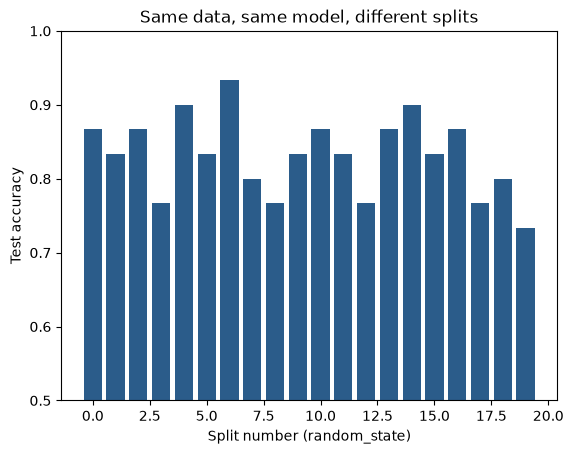

Lowest 73%, highest 93%, average 83%


In [16]:
seeds = range(20)
scores = [test_accuracy_for_split(s) for s in seeds]    # TODO: loop over the seeds

plt.bar(seeds, scores, color="#2B5C8A")
plt.xlabel("Split number (random_state)")
plt.ylabel("Test accuracy")
plt.ylim(0.5, 1)
plt.title("Same data, same model, different splits")
plt.show()

print(f"Lowest {min(scores):.0%}, highest {max(scores):.0%}, average {np.mean(scores):.0%}")

**Question 7:** Why does the test accuracy change from split to split? Should we trust a single test score on its own?

*Your answer:*
    Becase the seeds number is changed, which means the training material will also changed which cause a difference variable in that algorithm. It is better to not trust a single test score on its own in case there is some unpredictable error occur in that one single test.

## Part 8: Measure performance properly
Back to our model from Part 6. We will treat **orange** as the "positive" class.

### Exercise 8.1: Confusion matrix

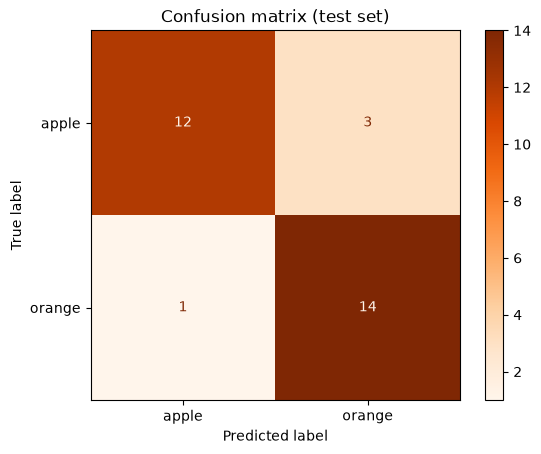

In [18]:
y_pred = model.predict(X_test_scaled)                  # TODO: predict the scaled test data

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Oranges")
plt.title("Confusion matrix (test set)")
plt.show()

**How to read it:** rows are the **true** fruit, columns are what the model **predicted**. The diagonal (top-left to bottom-right) shows correct answers; the other two boxes are mistakes.

### Exercise 8.2: Accuracy, precision and recall

In [19]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.0%}   (how often it is right overall)")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='orange'):.0%}   (when it says orange, how often is it right?)")
# TODO: replace ... with recall_score(y_test, y_pred, pos_label='orange')
print(f"Recall:    {recall_score(y_test, y_pred, pos_label='orange'):.0%}   (of the real oranges, how many did it find?)")
print()
print(classification_report(y_test, y_pred))

Accuracy:  87%   (how often it is right overall)
Precision: 82%   (when it says orange, how often is it right?)
Recall:    93%   (of the real oranges, how many did it find?)

              precision    recall  f1-score   support

       apple       0.92      0.80      0.86        15
      orange       0.82      0.93      0.88        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



**Question 8:** Using the confusion matrix, check the precision for oranges by hand: (oranges correctly predicted) ÷ (everything predicted as orange).

*Your answer:*
    14 ÷ (14 + 3) = 0.8235294117647059

## Extension: How many neighbours?
Try `n_neighbors` = 1, 5 and 25. Compare training and test accuracy for each.

In [ ]:
for k in [1, 5, 25]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    print(f"k={k:>2}: training {knn.score(X_train_scaled, y_train):.0%}, test {knn.score(X_test_scaled, y_test):.0%}")

# TODO (written): which value of k overfits? How can you tell?
# The k = 1 is overfits. Because it has 100% score in training but its test score is lower than others value of k.

k= 1: training 100%, test 83%
k= 5: training 87%, test 87%
k=25: training 83%, test 90%
